In [65]:
import numpy as np
import pandas as pd
import os 
import random
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
booksExcel = pd.read_excel("kitap-veri.xlsx")
'print(booksExcel.head())'
df = booksExcel[booksExcel["cDurumu"] == "Mevcut"]
df.to_excel("kitap-veri_guncel.xlsx", index=False)
print('sonuç kaydedildi')

C:\Users\90537\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


sonuç kaydedildi


In [19]:
print("Çalıştığın dizin:", os.getcwd())
print("Bu dizindeki dosyalar:", os.listdir())

Çalıştığın dizin: C:\Users\90537\Desktop\Kütüphane-Projesi
Bu dizindeki dosyalar: ['.ipynb_checkpoints', 'kitap-veri.xlsx', 'kitap_odunc_listesi.xlsx', 'ogrenci_listesi.xlsx', 'Orhan-Cevili-tur.xlsx', 'Orhanlı_cevizli.xlsx', 'Orhanlı_cevizli_tum_sayfalar_tur_eklenmis.xlsx', 'Orhanlı_cevizli_tur_eklenmis.xlsx', 'Untitled.ipynb']


In [28]:
lc_map = {
    "A": "Genel Yapıtlar",
    "B": "Felsefe, Psikoloji, Din",
    "C": "Tarihe Yardımcı Bilimler",
    "D": "Tarih",
    "E": "Tarih",
    "F": "Tarih",
    "G": "Coğrafya",
    "H": "Sosyal Bilimler",
    "J": "Siyaset Bilimi",
    "K": "Hukuk",
    "L": "Eğitim",
    "M": "Müzik",
    "N": "Güzel Sanatlar",
    "P": "Dil ve Edebiyat",
    "Q": "Bilim",
    "R": "Tıp",
    "S": "Tarım",
    "T": "Teknoloji",
    "U": "Askerlik",
    "V": "Denizcilik",
    "Z": "Kaynakçalar"
}
df = pd.read_excel("kitap-veri_guncel.xlsx")
def lc_category(value):
    if isinstance(value, str) and len(value) > 0:
        first_char = value.strip()[0].upper()
        return lc_map.get(first_char, "Bilinmeyen")
    else:
        return "Bilinmeyen"

df["LC_Kategori"] = df["KATALOG_03::kunyeSiniflamaYer"].apply(lc_category)
df.to_excel("kitap-veri_sinifli.xlsx", index=False)
print("LC kategorisi eklendi ve yeni Excel dosyası kaydedildi.")

✅ LC kategorisi eklendi ve yeni Excel dosyası kaydedildi.


In [42]:
df = pd.read_excel("kitap-veri_sinifli.xlsx")

# Kontrol etmek istediğin sütunun adı
column = "kunyeDemirbasKN"

# Eşsizlik ve boşluk kontrolü
is_unique = df[column].is_unique
has_no_nulls = df[column].notnull().all()

if is_unique and has_no_nulls:
    print(f"'{column}' sütunu Primary Key ")
else:
    print(f"'{column}' sütunu Primary Key değildir ")
    print(f"- Tekrarlı değer var mı: {not is_unique}")
    print(f"- Boş değer var mı: {not has_no_nulls}")

'kunyeDemirbasKN' sütunu Primary Key 


In [53]:
print(df.columns.tolist())
df = df.drop(columns=["KGTZ"])
df.to_excel("kitap-veri_sinifli.xlsx", index=False)
print(' KGTZ sütunu silindi')

['KGTZ', 'kunyeDemirbasKN', 'sayimAciklama', 'kunyeEserAdiYazarlar', 'KATALOG_03::kunyeSiniflamaYer', 'KATALOG_03::kunyeKutuphaneKN', 'KATALOG_03::kunyeBolumKN', 'cDurumu', 'sayimNo', 'LC_Kategori']
iş bitti


In [ ]:
print(df.columns.tolist())
df = df.drop(columns=["sayimAciklama"])
df.to_excel("kitap-veri_sinifli.xlsx", index=False)

In [69]:
def remove_column_from_excel(file_path, column_name, output_path=None):
    """
    Excel dosyasından belirtilen sütunu siler ve sonucu kaydeder.

    :param file_path: Giriş Excel dosyası yolu
    :param column_name: Silinecek sütun adı
    :param output_path: Çıktı dosyası yolu (None ise orijinal dosyanın üstüne yazar)
    """
    # Excel'i oku
    df = pd.read_excel(file_path)
    
    # Sütun adlarını temizle (başında/sonunda boşluk varsa)
    df.columns = df.columns.str.strip()
    
    # Sütunu sil (hata vermemesi için errors='ignore')
    df = df.drop(columns=[column_name], errors='ignore')
    
    # Çıktı dosya yolu
    if output_path is None:
        output_path = file_path  # Orijinal dosyanın üstüne yaz
    
    # Kaydet
    df.to_excel(output_path, index=False)
    print(f"✅ '{column_name}' sütunu silindi ve dosya kaydedildi: {output_path}")

In [71]:
print(df.columns.tolist())

['kunyeDemirbasKN', 'kunyeEserAdiYazarlar', 'KATALOG_03::kunyeSiniflamaYer', 'KATALOG_03::kunyeKutuphaneKN', 'KATALOG_03::kunyeBolumKN', 'cDurumu', 'sayimNo', 'LC_Kategori']


In [74]:
remove_column_from_excel("kitap-veri_sinifli.xlsx","sayimNo")

✅ 'sayimNo' sütunu silindi ve dosya kaydedildi: kitap-veri_sinifli.xlsx


In [75]:
remove_column_from_excel("kitap-veri_sinifli.xlsx","KATALOG_03::kunyeKutuphaneKN")
remove_column_from_excel("kitap-veri_sinifli.xlsx","KATALOG_03::kunyeBolumKN")


✅ 'KATALOG_03::kunyeKutuphaneKN' sütunu silindi ve dosya kaydedildi: kitap-veri_sinifli.xlsx
✅ 'KATALOG_03::kunyeBolumKN' sütunu silindi ve dosya kaydedildi: kitap-veri_sinifli.xlsx


In [11]:
df = pd.read_excel("kitap_odunc_listesi.xlsx")
counts = df["Kitap ID"].value_counts()
print(counts[counts == 2])

Kitap ID
1050892    2
1596595    2
5992316    2
5206966    2
2992888    2
6250563    2
5207938    2
7573397    2
7216628    2
2868039    2
7459845    2
Name: count, dtype: int64


In [31]:
print(len(df["Kitap ID"]))

13436


In [39]:
kayit_df = pd.read_excel("ogrenci_listesi.xlsx")
odunc_df = pd.read_excel("kitap_odunc_listesi.xlsx")

#  Ortak sütun: öğrenci numarası
# (örneğin iki dosyada da "OgrenciNo" sütunu var diyelim)
# Eğer isimler farklıysa, örneğin biri "Numara", biri "OgrenciNo" ise, merge’de belirtiriz.

#  Cinsiyet bilgisini ekle (merge işlemiyle)
birlesik_df = odunc_df.merge(kayit_df[["ÖğrenciKimlik-no", "Cinsiyet"]], on="ÖğrenciKimlik-no", how="left")

#  Sonucu kaydet
birlesik_df.to_excel("odunc_listesi_cinsiyetli.xlsx", index=False)

print(" Cinsiyet bilgisi başarıyla eklendi ve yeni dosya oluşturuldu: odunc_listesi_cinsiyetli.xlsx")

✅ Cinsiyet bilgisi başarıyla eklendi ve yeni dosya oluşturuldu: odunc_listesi_cinsiyetli.xlsx


In [41]:
kayit_df = pd.read_excel("ogrenci_listesi.xlsx")
odunc_df = pd.read_excel("odunc_listesi_cinsiyetli.xlsx")

#  Ortak sütun: öğrenci numarası
# (örneğin iki dosyada da "OgrenciNo" sütunu var diyelim)
# Eğer isimler farklıysa, örneğin biri "Numara", biri "OgrenciNo" ise, merge’de belirtiriz.

#  Cinsiyet bilgisini ekle (merge işlemiyle)
birlesik_df = odunc_df.merge(kayit_df[["ÖğrenciKimlik-no", "Fakülte"]], on="ÖğrenciKimlik-no", how="left")

#  Sonucu kaydet
birlesik_df.to_excel("odunc_listesi_fakulteli.xlsx", index=False)

print(" yeni dosya oluşturuldu: odunc_listesi_fakulteli.xlsx")

 Cinsiyet bilgisi başarıyla eklendi ve yeni dosya oluşturuldu: odunc_listesi_fakulteli.xlsx


In [43]:
kayit_df = pd.read_excel("ogrenci_listesi.xlsx")
odunc_df = pd.read_excel("odunc_listesi_fakulteli.xlsx")

#  Ortak sütun: öğrenci numarası
# (örneğin iki dosyada da "OgrenciNo" sütunu var diyelim)
# Eğer isimler farklıysa, örneğin biri "Numara", biri "OgrenciNo" ise, merge’de belirtiriz.

#  Cinsiyet bilgisini ekle (merge işlemiyle)
birlesik_df = odunc_df.merge(kayit_df[["ÖğrenciKimlik-no", "Bölüm"]], on="ÖğrenciKimlik-no", how="left")

#  Sonucu kaydet
birlesik_df.to_excel("odunc_listesi_guncel.xlsx", index=False)

print(" Son guncel hali oldu: odunc_listesi_guncel.xlsx")

 Son guncel hali oldu: odunc_listesi_guncel.xlsx


In [59]:
odunc_df = pd.read_excel("odunc_listesi_guncel.xlsx")
kitap_df = pd.read_excel("kitap-veri_sinifli.xlsx")

# Sütun adlarını temizle
odunc_df.columns = odunc_df.columns.str.strip()
kitap_df.columns = kitap_df.columns.str.strip()

#  Eşleştirme yapılacak sütunları stringe çevir
odunc_df["Kitap ID"] = odunc_df["Kitap ID"].astype(str)
kitap_df["kunyeDemirbasKN"] = kitap_df["kunyeDemirbasKN"].astype(str)

# Birleştirme
birlesik_df = odunc_df.merge(
    kitap_df[["kunyeDemirbasKN", "kunyeEserAdiYazarlar"]],
    left_on="Kitap ID",
    right_on="kunyeDemirbasKN",
    how="left"
)

# Kaydet
birlesik_df.to_excel("odunc_listesi_kitapli.xlsx", index=False)
print(" birleştirme tamamlandı!")

 birleştirme tamamlandı!


In [61]:
df = pd.read_excel("odunc_listesi_guncel.xlsx")
counts = df["Fakülte"].value_counts()
print(counts)

Fakülte
Hukuk Fakültesi                            1281
Siyasal Bilgiler Fakültesi                 1281
Sağlık Bilimleri Fakültesi                 1279
İlahiyat Fakültesi                         1257
Diş Hekimliği Fakültesi                    1252
Sanat, Tasarım ve Mimarlık Fakültesi       1237
Mühendislik ve Doğa Bilimleri Fakültesi    1227
Edebiyat Fakültesi                         1185
Turizm Fakültesi                           1175
Eğitim Bilimleri Fakültesi                 1152
Tıp Fakültesi                              1110
Name: count, dtype: int64


In [63]:
df = pd.read_excel("kitap-veri_sinifli.xlsx")
counts = df["LC_Kategori"].value_counts()
print(counts)

LC_Kategori
Dil ve Edebiyat             32609
Tarih                       17290
Felsefe, Psikoloji, Din     16517
Hukuk                       13375
Sosyal Bilimler             11320
Siyaset Bilimi               5022
Tıp                          4150
Bilim                        3697
Eğitim                       2903
Güzel Sanatlar               2454
Coğrafya                     2001
Teknoloji                    1733
Müzik                         813
Kaynakçalar                   763
Tarihe Yardımcı Bilimler      742
Genel Yapıtlar                404
Tarım                         297
Askerlik                      275
Denizcilik                     36
Bilinmeyen                     21
Name: count, dtype: int64


In [67]:
df = pd.read_excel("kitap-veri_sinifli.xlsx")

#  Kategori sütun adını kontrol et (gerekirse burayı değiştir)
kategori_sutun = "LC_Kategori"

#  Her kategoriye karşılık gelen ön ekleri tanımla
kategori_prefix = {
    "Dil ve Edebiyat": "DE",
    "Tarih": "T",
    "Felsefe, Psikoloji, Din": "FPD",
    "Hukuk": "H",
    "Sosyal Bilimler": "So",
    "Siyaset Bilimi": "Si",
    "Tıp": "Tip",
    "Bilim": "B",
    "Eğitim": "E",
    "Güzel Sanatlar": "GS",
    "Coğrafya": "C",
    "Teknoloji": "Tec",
    "Müzik": "M",
    "Kaynakçalar": "K",
    "Tarihe Yardımcı Bilimler": "TYB",
    "Genel Yapıtlar": "GY",
    "Tarım": "Trm",
    "Askerlik": "A",
    "Denizcilik": "Dn",
    "Bilinmeyen": "N"
}

#  Her kategori içinde sıra numarasını üret ve ID sütununa ata
df["Kategori_Sira"] = df.groupby(kategori_sutun).cumcount() + 1
df["ID"] = df.apply(lambda x: f"{kategori_prefix.get(x[kategori_sutun], 'X')}{x['Kategori_Sira']}", axis=1)

#  Artık geçici sütunu silebiliriz
df.drop(columns=["Kategori_Sira"], inplace=True)

#  Sonucu kaydet
df.to_excel("kitap-veri-sinifli-idli.xlsx", index=False)

print("Yeni dosya: kitap-veri-sinifli-idli.xlsx")

Yeni dosya: kitap-veri-sinifli-idli.xlsx


In [70]:
df = pd.read_excel("kitap-veri-sinifli-idli.xlsx")
counts = df["ID"].value_counts()
print(counts)

ID
FPD1       1
GS1796     1
H8942      1
H8941      1
B2456      1
          ..
B1490      1
DE14733    1
DE14732    1
DE14731    1
Si5022     1
Name: count, Length: 116422, dtype: int64


In [74]:
# 'ID' sütununuzdaki harfleri ayıklayıp 'Kategori' adlı yeni bir sütun oluşturun
df['Kategori'] = df['ID'].str.extract(r'([A-Za-z]+)')
print(df["Kategori"].value_counts())

Kategori
DE     32609
T      17290
FPD    16517
H      13375
So     11320
Si      5022
Tip     4150
B       3697
E       2903
GS      2454
C       2001
Tec     1733
M        813
K        763
TYB      742
GY       404
Trm      297
A        275
Dn        36
N         21
Name: count, dtype: int64


In [82]:
odunc_df = pd.read_excel("odunc_listesi_son.xlsx")
kitap_df = pd.read_excel("kitap-veri-sinifli-idli.xlsx")

# Boşlukları temizle
odunc_df.columns = odunc_df.columns.str.strip()
kitap_df.columns = kitap_df.columns.str.strip()

# -----------------------------

# -----------------------------
# Yöntem 1: map kullanarak
id_to_name = dict(zip(kitap_df["ID"], kitap_df["kunyeEserAdiYazarlar"]))
odunc_df["Kitap Adı-Yazar"] = odunc_df["Kitap-ID"].map(id_to_name)

# -----------------------------

# -----------------------------
odunc_df.to_excel("odunc_listesi_son_kitaplar.xlsx", index=False)

print(" odunc_listesi_son_kitaplar.xlsx oluşturuldu.")

 odunc_listesi_son_kitaplar.xlsx oluşturuldu.


In [29]:
#Boş sütun var mı kontrolü 
df = pd.read_excel("odunc_listesi_son_kitaplar.xlsx")
print('Boş sütun var mı')
print(df.isnull().sum())
#Tekrarlanan değer var mı ?
print('Tekrarlanan satır var mı ?')
print(df.duplicated().sum())
silinecekler=["Kitap ID", "Kitap Adı-Yazar", "Alış Tarihi" , "Getiriş Tarihi"]
df=df.drop(columns=silinecekler)
df.to_excel("OduncListesi_Güncel.xlsx", index=False)

Boş sütun var mı
ÖğrenciKimlik-no    0
Kitap ID            0
Alış Tarihi         0
Getiriş Tarihi      0
Cinsiyet            0
Fakülte             0
Bölüm               0
Kitap-ID            0
Kitap Adı-Yazar     0
dtype: int64
Tekrarlanan satır var mı ?
0


In [25]:
# Aykırı Değerler Kontrolü
print('Cinsiyet kısmında benzersiz değerler')
print(df["Cinsiyet"].unique())
print('Fakülte kısmında benzersiz değerler')
print(df["Fakülte"].unique())
print('Bölüm kısmında benzersiz değerler')
print(df["Bölüm"].unique())

Cinsiyet kısmında benzersiz değerler
['Kadın' 'Erkek']
Fakülte kısmında benzersiz değerler
['Turizm Fakültesi' 'Mühendislik ve Doğa Bilimleri Fakültesi'
 'Sağlık Bilimleri Fakültesi' 'Edebiyat Fakültesi' 'Hukuk Fakültesi'
 'Siyasal Bilgiler Fakültesi' 'Sanat, Tasarım ve Mimarlık Fakültesi'
 'Tıp Fakültesi' 'Eğitim Bilimleri Fakültesi' 'Diş Hekimliği Fakültesi'
 'İlahiyat Fakültesi']
Bölüm kısmında benzersiz değerler
['Gastronomi ve Mutfak Sanatları' 'Biyomühendislik' 'Odyoloji'
 'Sosyoloji Bölümü' 'Hukuk Bölümü' 'Siyaset Bilimi ve Kamu Yönetimi'
 'Bilim Tarihi Bölümü' 'Hemşirelik' 'Mimarlık' 'Tıp Bölümü'
 'Uçak Mühendisliği' 'Matematik ve Fen Bilimleri Eğitimi'
 'Uzay Mühendisliği' 'Fizik Mühendisliği' 'Diş Hekimliği Bölümü'
 'Bilgi ve Belge Yönetimi Bölümü' 'Elektrik-Elektronik Mühendisliği'
 'Sanat Tarihi Bölümü' 'Felsefe ve Din Bilimleri' 'Özel Eğitim' 'İktisat'
 'Güzel Sanatlar Eğitimi' 'Şehir ve Bölge Planlama' 'İşletme'
 'Temel İslam Bilimleri' 'Psikoloji Bölümü' 'Biyomedikal Müh

In [14]:
df = pd.read_excel("OduncListesi_Güncel.xlsx")
kitaplar_df= pd.read_excel("kitap-veri-sinifli-idli.xlsx")
print('Kitaplar tablosunda boş değer varm  mı ?')
print(kitaplar_df.isnull().sum())
print('Tekrarlanan satır var mı ?')
print(kitaplar_df.duplicated().sum())


Kitaplar tablosunda boş değer varm  mı ?
kunyeDemirbasKN                  0
kunyeEserAdiYazarlar             0
KATALOG_03::kunyeSiniflamaYer    5
cDurumu                          0
LC_Kategori                      0
ID                               0
dtype: int64
Tekrarlanan satır var mı ?
0


In [15]:
#Burada kitapların Kategorisini OduncListesinde tutuyorum sadece tek bir excel tablosunda yapcam
birlesik_df = df.merge(
    kitaplar_df[['ID', 'LC_Kategori']],
    how='left',                     # Eşleşmeyenler NaN kalır
    left_on='Kitap-ID',             # ödünç listesinde Kitap-ID
    right_on='ID'                   # kitaplar tablosunda ID
)
birlesik_df.drop(columns=['ID'], inplace=True) # Geçici ID sütununu sildim
birlesik_df.to_excel("Odunc_Guncel_Kategorili_Liste.xlsx", index=False)

In [16]:
df = pd.read_excel("Odunc_Guncel_Kategorili_Liste.xlsx")


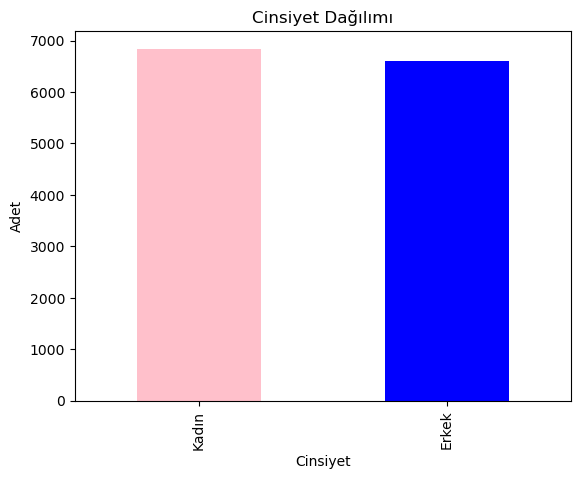

In [17]:
df['Cinsiyet'].value_counts().plot(kind='bar', color=['pink','blue'])
plt.title("Cinsiyet Dağılımı")
plt.ylabel("Adet")
plt.show()


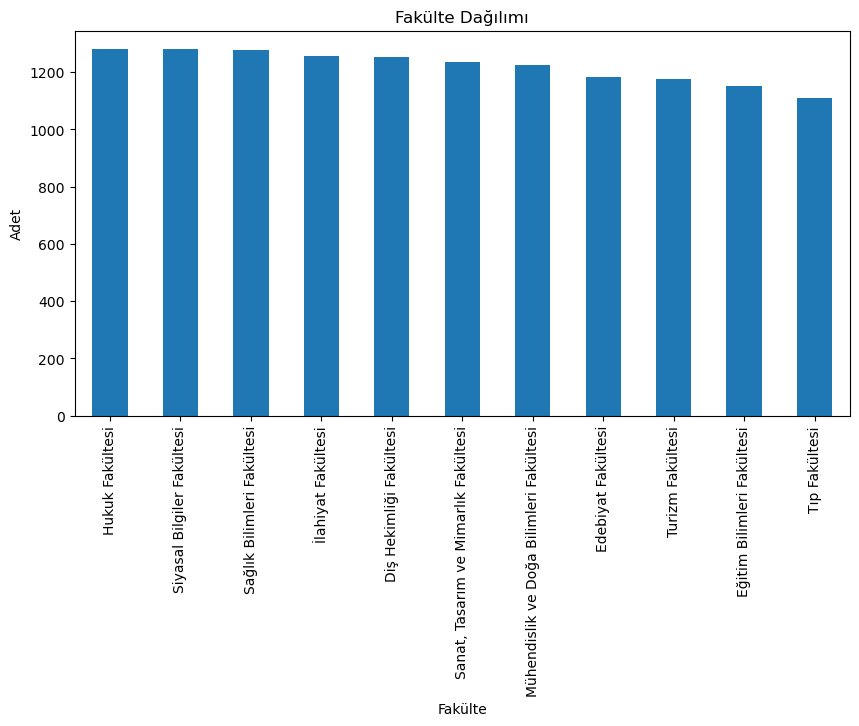

In [57]:
df['Fakülte'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Fakülte Dağılımı")
plt.ylabel("Adet")
plt.show()

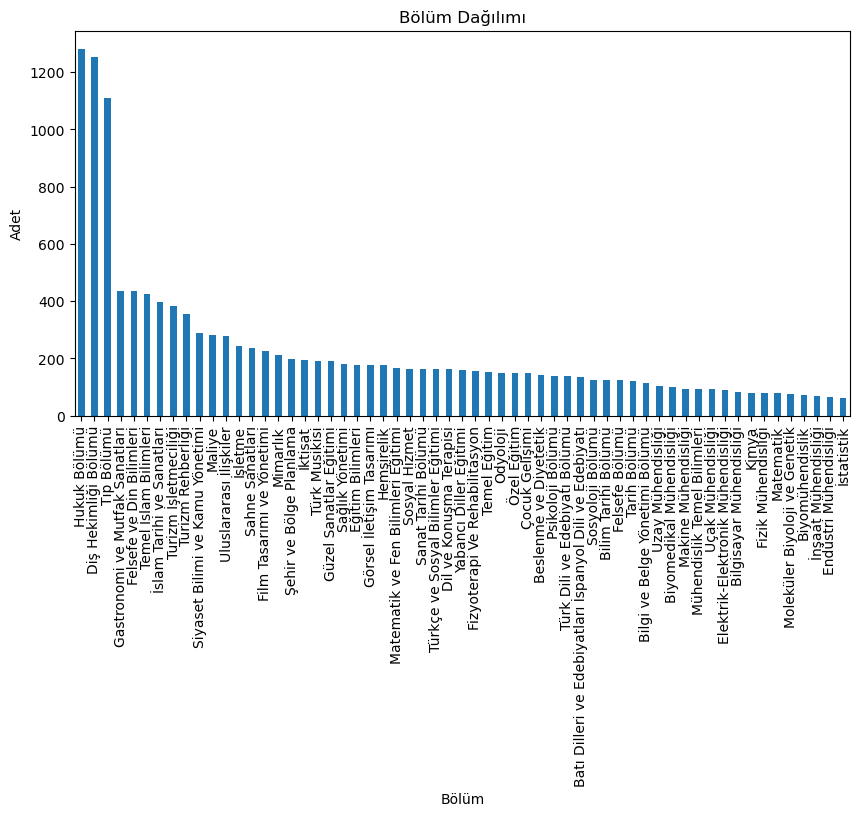

In [61]:
df['Bölüm'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Bölüm Dağılımı")
plt.ylabel("Adet")
plt.show()

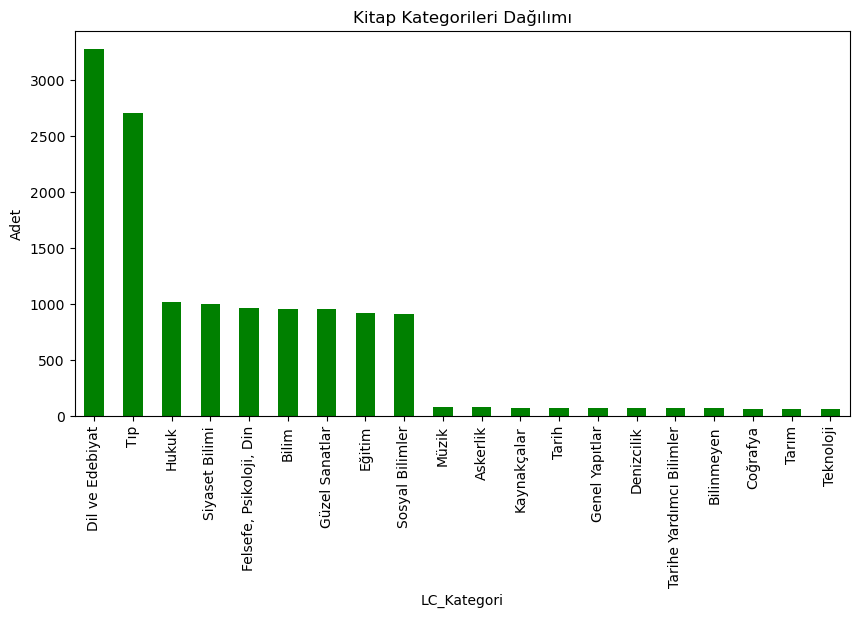

In [63]:
df['LC_Kategori'].value_counts().plot(kind='bar', figsize=(10,5), color='green')
plt.title("Kitap Kategorileri Dağılımı")
plt.ylabel("Adet")
plt.show()

In [ ]:
df['LC_Kategori'].value_counts(normalize=True)


In [83]:
pd.crosstab(df['Cinsiyet'], df['LC_Kategori'], normalize='index')


LC_Kategori,Askerlik,Bilim,Bilinmeyen,Coğrafya,Denizcilik,Dil ve Edebiyat,Eğitim,"Felsefe, Psikoloji, Din",Genel Yapıtlar,Güzel Sanatlar,Hukuk,Kaynakçalar,Müzik,Siyaset Bilimi,Sosyal Bilimler,Tarih,Tarihe Yardımcı Bilimler,Tarım,Teknoloji,Tıp
Cinsiyet,,,,,,,,,,,,,,,,,,,,
Erkek,0.005762,0.074147,0.004397,0.004549,0.005155,0.237908,0.066414,0.072176,0.006368,0.067779,0.076270,0.006368,0.005459,0.074905,0.071266,0.005459,0.005155,0.004701,0.004246,0.201516
Kadın,0.005262,0.068411,0.005409,0.004970,0.005116,0.249233,0.069434,0.071481,0.003947,0.073820,0.074989,0.004385,0.006286,0.074112,0.063441,0.005116,0.004824,0.004678,0.004239,0.200848


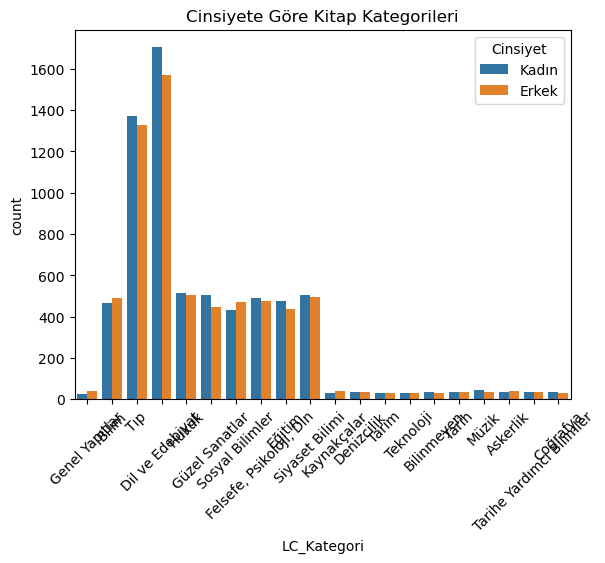

In [79]:
sns.countplot(x='LC_Kategori', hue='Cinsiyet', data=df)
plt.xticks(rotation=45)
plt.title("Cinsiyete Göre Kitap Kategorileri")
plt.show()

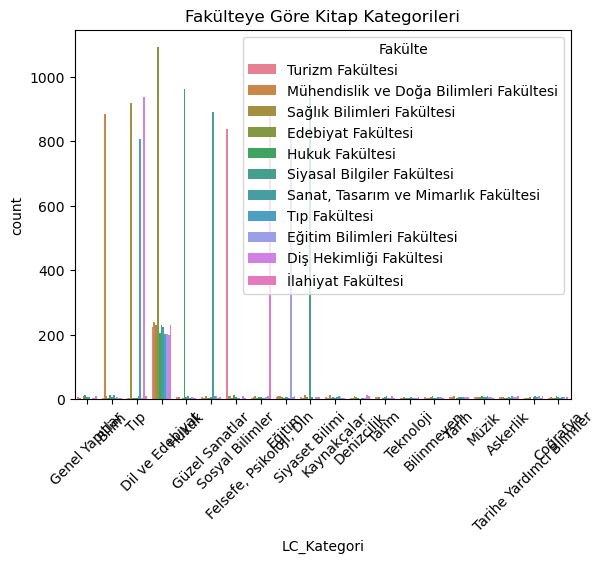

In [77]:
sns.countplot(x='LC_Kategori', hue='Fakülte', data=df)
plt.xticks(rotation=45)
plt.title("Fakülteye Göre Kitap Kategorileri")
plt.show()

In [23]:
from scipy.stats import chi2_contingency

# Örnek: Cinsiyet ve LC_Kategori arasındaki ilişki
ct = pd.crosstab(df['Cinsiyet'], df['LC_Kategori'])
chi2, p, dof, expected = chi2_contingency(ct)
# burada kategorik kategerik bir veri seti olduğu için Chi-square testini uygularız
print("Chi-square Değeri:", chi2)
print("p-değeri:", p)
#p değeri 0.05den büyük çıktı ve bi anlamsal ilişki yok

ct = pd.crosstab(df['Fakülte'], df['LC_Kategori'])
chi2, p, dof, expected = chi2_contingency(ct)
print("p-değeri:", p)
# p değeri 0.0 0.05den küçük ve bağlantılı olduğu yüksek yani kategori ile tıp fakülteliler tıp kitabını edebiyat fakültesi edebiyat kitabı almış gibi görünüyor

Chi-square Değeri: 16.50172716194188
p-değeri: 0.6235845807961924
p-değeri: 0.0


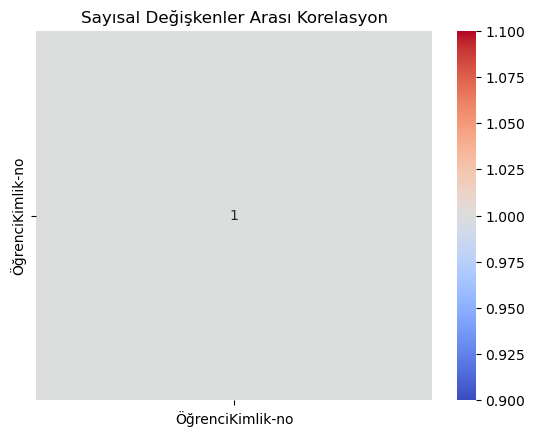

In [25]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title("Sayısal Değişkenler Arası Korelasyon")
plt.show()

In [27]:
# Fakülte dağılımı
print(df['Fakülte'].value_counts())

# Bölüm dağılımı
print(df['Bölüm'].value_counts())

# Cinsiyet dağılımı
print(df['Cinsiyet'].value_counts())

# Kitap kategorisi dağılımı
print(df['LC_Kategori'].value_counts())

Fakülte
Hukuk Fakültesi                            1281
Siyasal Bilgiler Fakültesi                 1281
Sağlık Bilimleri Fakültesi                 1279
İlahiyat Fakültesi                         1257
Diş Hekimliği Fakültesi                    1252
Sanat, Tasarım ve Mimarlık Fakültesi       1237
Mühendislik ve Doğa Bilimleri Fakültesi    1227
Edebiyat Fakültesi                         1185
Turizm Fakültesi                           1175
Eğitim Bilimleri Fakültesi                 1152
Tıp Fakültesi                              1110
Name: count, dtype: int64
Bölüm
Hukuk Bölümü                                               1281
Diş Hekimliği Bölümü                                       1252
Tıp Bölümü                                                 1110
Gastronomi ve Mutfak Sanatları                              435
Felsefe ve Din Bilimleri                                    435
Temel İslam Bilimleri                                       424
İslam Tarihi ve Sanatları                       

In [101]:
# Aynı öğrenci + aynı kitap kombinasyonu
duplikatlar = df.duplicated(subset=['ÖğrenciKimlik-no','Kitap-ID'])
print(df[duplikatlar])

Empty DataFrame
Columns: [ÖğrenciKimlik-no, Cinsiyet, Fakülte, Bölüm, Kitap-ID, LC_Kategori]
Index: []


In [103]:
pd.crosstab(df['Cinsiyet'], df['LC_Kategori'])

LC_Kategori,Askerlik,Bilim,Bilinmeyen,Coğrafya,Denizcilik,Dil ve Edebiyat,Eğitim,"Felsefe, Psikoloji, Din",Genel Yapıtlar,Güzel Sanatlar,Hukuk,Kaynakçalar,Müzik,Siyaset Bilimi,Sosyal Bilimler,Tarih,Tarihe Yardımcı Bilimler,Tarım,Teknoloji,Tıp
Cinsiyet,,,,,,,,,,,,,,,,,,,,
Erkek,38,489,29,30,34,1569,438,476,42,447,503,42,36,494,470,36,34,31,28,1329
Kadın,36,468,37,34,35,1705,475,489,27,505,513,30,43,507,434,35,33,32,29,1374


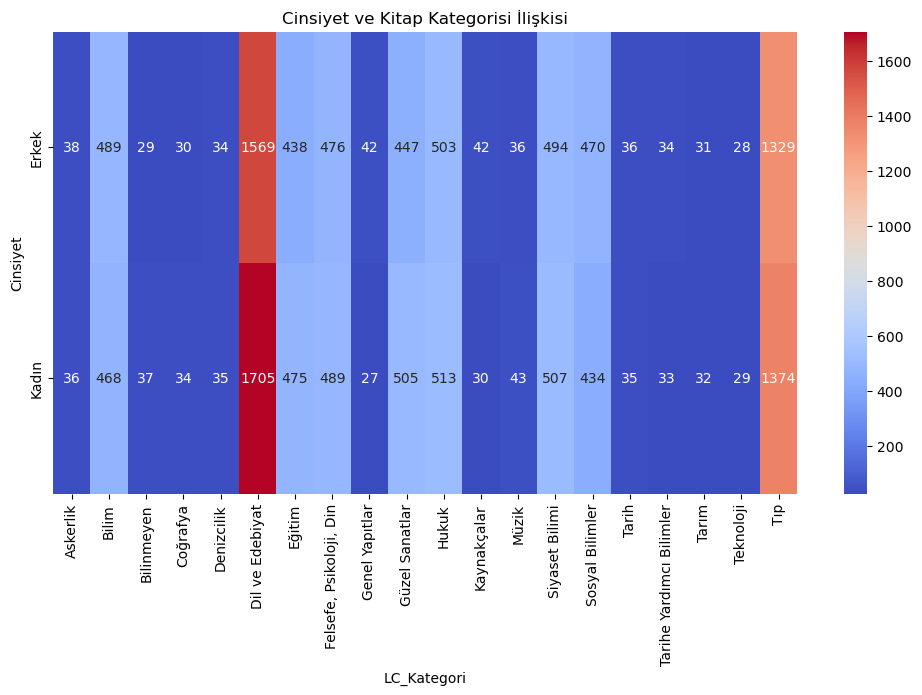

In [107]:
plt.figure(figsize=(12,6)) 
sns.heatmap(pd.crosstab(df['Cinsiyet'], df['LC_Kategori']), annot=True, cmap='coolwarm', fmt='d')
plt.title("Cinsiyet ve Kitap Kategorisi İlişkisi")
plt.show()

In [21]:
#Boş olan sütunları Bilinmiyor olarak yaptık daha doğru bir yöntem ama genelde boş olan sütunumuz yok 
df['Cinsiyet'] = df['Cinsiyet'].fillna("Bilinmiyor")
df['Fakülte'] = df['Fakülte'].fillna("Bilinmiyor")
df['Bölüm'] = df['Bölüm'].fillna("Bilinmiyor")
df['LC_Kategori'] = df['LC_Kategori'].fillna("Bilinmiyor")

In [15]:
#            7 Veri Planı Hazırlama 
#Temizleme kısmı
print('Eksik Veri Var mı Sütunlarda ?')
print(print(df.isnull().sum()))


Eksik Veri Var mı Sütunlarda ?
ÖğrenciKimlik-no    0
Cinsiyet            0
Fakülte             0
Bölüm               0
Kitap-ID            0
LC_Kategori         0
dtype: int64
None


In [7]:
# Sütunların hepsi Ya ID yada Kategorik veriler ile dolu olduğunu görüyoruz
#Transformations Dönüşümler modelin anlayabilmesi için sayısal forma dönüştürmemiz gerekiyor Verilerimiz kategorik veriler 
# olduğu için biz bunları Encoding yapacağız  Ölçekleme/Normalizasyon  veya Log Formasyonu sayısal olmadığı için uygulayamayız.
from sklearn.preprocessing import LabelEncoder
    
le = LabelEncoder()
df['Cinsiyet'] = le.fit_transform(df['Cinsiyet']) #1 kadın 0 erkek olarak sayısal olarak sütuna çevirdik
df.to_excel("Odunc_Guncel_Kategorili_Liste.xlsx",index=False)

In [43]:
#One-Hot Encoding (Sırasız Kategori için)
print(df['LC_Kategori'].unique())

['Genel Yapıtlar' 'Bilim' 'Tıp' 'Dil ve Edebiyat' 'Hukuk' 'Güzel Sanatlar'
 'Sosyal Bilimler' 'Felsefe, Psikoloji, Din' 'Eğitim' 'Siyaset Bilimi'
 'Kaynakçalar' 'Denizcilik' 'Tarım' 'Teknoloji' 'Bilinmeyen' 'Tarih'
 'Müzik' 'Askerlik' 'Tarihe Yardımcı Bilimler' 'Coğrafya']


In [13]:
print(df.columns)

Index(['ÖğrenciKimlik-no', 'Cinsiyet', 'Bölüm', 'Kitap-ID',
       'Fakülte_Diş Hekimliği Fakültesi', 'Fakülte_Edebiyat Fakültesi',
       'Fakülte_Eğitim Bilimleri Fakültesi', 'Fakülte_Hukuk Fakültesi',
       'Fakülte_Mühendislik ve Doğa Bilimleri Fakültesi',
       'Fakülte_Sanat, Tasarım ve Mimarlık Fakültesi',
       'Fakülte_Sağlık Bilimleri Fakültesi',
       'Fakülte_Siyasal Bilgiler Fakültesi', 'Fakülte_Turizm Fakültesi',
       'Fakülte_Tıp Fakültesi', 'Fakülte_İlahiyat Fakültesi',
       'LC_Kategori_Askerlik', 'LC_Kategori_Bilim', 'LC_Kategori_Bilinmeyen',
       'LC_Kategori_Coğrafya', 'LC_Kategori_Denizcilik',
       'LC_Kategori_Dil ve Edebiyat', 'LC_Kategori_Eğitim',
       'LC_Kategori_Felsefe, Psikoloji, Din', 'LC_Kategori_Genel Yapıtlar',
       'LC_Kategori_Güzel Sanatlar', 'LC_Kategori_Hukuk',
       'LC_Kategori_Kaynakçalar', 'LC_Kategori_Müzik',
       'LC_Kategori_Siyaset Bilimi', 'LC_Kategori_Sosyal Bilimler',
       'LC_Kategori_Tarih', 'LC_Kategori_Tarihe Yar

In [ ]:
# 10 + 20 sütun oluşturacağı için bu makul bir seviye olabilir Fakülte ve LC_Kategori için onun  için 
# LC Kategori ve Fakülte için One-Hot Encoding yöntemi ile yapacağız 
df = pd.get_dummies(df, columns=['Fakülte', 'LC_Kategori'])
df.to_excel("Odunc_Guncel_Kategorili_Liste2.xlsx",index=False)

In [57]:
#Bölüm çok fazla kategori olduğu için Artık “Bölüm” sütunu sayısal hale gelir, ve her değer o bölümün popülerliğiyle temsil edilir.
# Frequency Encoding Bu yöntem, her kategoriye o kategorinin veri setinde kaç kez geçtiğini (frekansını) verir.
# Burada en çok geçen bölüm o bölümün yüksek sayı en az geçen bölüm en düşük sayı verilir ve sayısal bir değer verilir Stringden başka
freq = df['Bölüm'].value_counts()
df['Bölüm'] = df['Bölüm'].map(freq)
df.to_excel("Odunc_Guncel_Kategorili_Liste.xlsx",index=False)
print('İşlem Tamamlandı')

İşlem Tamamlandı


In [59]:
# Kitap ID model için anlamlı olmadığı için çıkaryıoruz 
df = df.drop(columns=['Kitap-ID'])
# Bölüm frequency encoding çok fazla kategori olduu için bölüme yapıyoruz
freq = df['Bölüm'].value_counts() / len(df)
df['Bölüm_FE'] = df['Bölüm'].map(freq)
# Hedef Sütunumuz kitap kategorisini tahmin etmek olduğu için LC_Kategori sütunudur
target_cols = [col for col in df.columns if col.startswith('LC_Kategori_')]
# Özellik ve hedef sütunu ayırıyoruz
X = df.drop(columns=target_cols)
y = df[target_cols] 


In [63]:
from sklearn.model_selection import train_test_split
# Train ve Test Datayı Ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y[target_cols[0]]  # İlk LC_Kategori ile stratify
)
print('Ayrı train ve test dataları oluşturuldu ')

Ayrı train ve test dataları oluşturuldu 


In [67]:
from sklearn.feature_selection import mutual_info_classif
# Feature Selection ve Boyut İndirgeme
#Hedef: Hangi Fakülte/Bölüm veya önceki kitaplar LC_Kategori ile daha güçlü ilişkili var mı kontrolü? 
# Buarada önemli sütun e hedef sütunları belirlioruz


X = df.drop(columns=[col for col in df.columns if col.startswith('LC_Kategori_')] + ['ÖğrenciKimlik-no'])
y = df['LC_Kategori_Genel Yapıtlar']  # örnek: tek bir kategori tahmini

mi = mutual_info_classif(X, y)
feature_importance = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(feature_importance.head(10))

Cinsiyet                                        0.003018
Bölüm                                           0.001221
Fakülte_Tıp Fakültesi                           0.000886
Fakülte_Sağlık Bilimleri Fakültesi              0.000627
Fakülte_İlahiyat Fakültesi                      0.000473
Fakülte_Eğitim Bilimleri Fakültesi              0.000445
Fakülte_Hukuk Fakültesi                         0.000400
Bölüm_FE                                        0.000287
Fakülte_Sanat, Tasarım ve Mimarlık Fakültesi    0.000243
Fakülte_Diş Hekimliği Fakültesi                 0.000041
dtype: float64


In [69]:
# Wrapper Methods — RFE 
# RandomForest veya başka bir model ile hangi sütunlar gerçekten önemli ona bakabilirsin:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

selector = RFE(RandomForestClassifier(), n_features_to_select=10)
selector.fit(X, y)

selected_features = X.columns[selector.support_]
print(selected_features)

Index(['Cinsiyet', 'Bölüm', 'Fakülte_Edebiyat Fakültesi',
       'Fakülte_Eğitim Bilimleri Fakültesi', 'Fakülte_Hukuk Fakültesi',
       'Fakülte_Mühendislik ve Doğa Bilimleri Fakültesi',
       'Fakülte_Sanat, Tasarım ve Mimarlık Fakültesi',
       'Fakülte_Sağlık Bilimleri Fakültesi', 'Fakülte_İlahiyat Fakültesi',
       'Bölüm_FE'],
      dtype='object')


In [71]:
#Embedded Methods — Feature Importance
#RandomForest gibi modeller, kendi içinde feature importance verir: Böylece, modelin en çok hangi özellikleri kullandığını görebilirsin.
model = RandomForestClassifier().fit(X, y)
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))

Bölüm_FE                                           0.308226
Bölüm                                              0.302405
Cinsiyet                                           0.200060
Fakülte_Edebiyat Fakültesi                         0.033804
Fakülte_İlahiyat Fakültesi                         0.028479
Fakülte_Eğitim Bilimleri Fakültesi                 0.019318
Fakülte_Sağlık Bilimleri Fakültesi                 0.018288
Fakülte_Hukuk Fakültesi                            0.015897
Fakülte_Sanat, Tasarım ve Mimarlık Fakültesi       0.014887
Fakülte_Mühendislik ve Doğa Bilimleri Fakültesi    0.013903
dtype: float64


In [73]:
#PCA — Boyut İndirgeme
#Özellikle Fakülte ve LC_Kategori One-Hot sütunları için kullanmak istiyoruz.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)  # 10 bileşen
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(13436, 10)


In [75]:
df.to_excel('Base_Modele_Uygun_Hal.xlsx' ,index=False)
print('Kaydedildi')

Kaydedildi


In [39]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

#  Excel’den veri yükle
file_path = "Base_Modele_Uygun_Hal.xlsx"
df = pd.read_excel(file_path)

#  Hedef ve feature ayırma
lc_cols = [c for c in df.columns if c.startswith("LC_Kategori_")]
X = df.drop(columns=lc_cols + ['ÖğrenciKimlik-no'])  # features
y = df[lc_cols].idxmax(axis=1).str.replace("LC_Kategori_", "")  # çok sınıflı target

# Train/Test aşaması
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  RandomForest base model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

#  Eğit ve tahmin et
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

#  Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nF1 macro:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.7306547619047619

F1 macro: 0.345194857938531

Classification report:

                          precision    recall  f1-score   support

                Askerlik       0.00      0.00      0.00        15
                   Bilim       0.73      0.94      0.82       192
              Bilinmeyen       0.00      0.00      0.00        13
                Coğrafya       0.00      0.00      0.00        13
              Denizcilik       0.00      0.00      0.00        14
         Dil ve Edebiyat       0.87      0.29      0.43       655
                  Eğitim       0.76      0.89      0.82       183
 Felsefe, Psikoloji, Din       0.67      0.95      0.78       193
          Genel Yapıtlar       0.00      0.00      0.00        14
          Güzel Sanatlar       0.70      0.96      0.81       190
                   Hukuk       0.72      0.92      0.81       203
             Kaynakçalar       0.00      0.00      0.00        14
                   Müzik       0.00      0.00      0.00   

C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
# Genel performans
"""Accuracy: 0.73
F1 macro: 0.35


Accuracy 0.73 → model doğru tahmin yapıyor, ama çoğunluk sınıfına dayanıyor olabilir.

F1 macro 0.35 → sınıflar dengeli olmadığı için, küçük sınıflarda model neredeyse hiç tahmin yapamıyor.

 Sınıf bazlı durum

Bazı sınıflar (%0 performans):

Askerlik, Bilinmeyen, Coğrafya, Denizcilik, Genel Yapıtlar, Kaynakçalar, Müzik, Tarih, Tarihe Yardımcı Bilimler, Tarım, Teknoloji


Bu sınıflarda precision, recall, f1-score 0 → model bu sınıfları hiç tahmin etmemiş.

Bu, data seti dengesiz olduğu için oluyor (destek = support değerlerine bak: çoğu sınıf 10-15 örnek, bazıları 500+ örnek).

 Büyük sınıflar iyi
Dil ve Edebiyat: f1 0.43
Bilim: f1 0.82
Hukuk: f1 0.81
Tıp: f1 0.84


Model çoğunluk sınıflarda iyi çalışıyor.

Weighted avg (0.68) ve accuracy (0.73) çoğunluk sınıflar nedeniyle yüksek çıkmış.

 Uyarılar (UndefinedMetricWarning)

Precision is ill-defined... → küçük sınıflar için tahmin yok, bu yüzden precision tanımsız.

zero_division=0 parametresi ile 0 atanmış.

Index(['ÖğrenciKimlik-no', 'Cinsiyet', 'Bölüm',
       'Fakülte_Diş Hekimliği Fakültesi', 'Fakülte_Edebiyat Fakültesi',
       'Fakülte_Eğitim Bilimleri Fakültesi', 'Fakülte_Hukuk Fakültesi',
       'Fakülte_Mühendislik ve Doğa Bilimleri Fakültesi',
       'Fakülte_Sanat, Tasarım ve Mimarlık Fakültesi',
       'Fakülte_Sağlık Bilimleri Fakültesi',
       'Fakülte_Siyasal Bilgiler Fakültesi', 'Fakülte_Turizm Fakültesi',
       'Fakülte_Tıp Fakültesi', 'Fakülte_İlahiyat Fakültesi',
       'LC_Kategori_Askerlik', 'LC_Kategori_Bilim', 'LC_Kategori_Bilinmeyen',
       'LC_Kategori_Coğrafya', 'LC_Kategori_Denizcilik',
       'LC_Kategori_Dil ve Edebiyat', 'LC_Kategori_Eğitim',
       'LC_Kategori_Felsefe, Psikoloji, Din', 'LC_Kategori_Genel Yapıtlar',
       'LC_Kategori_Güzel Sanatlar', 'LC_Kategori_Hukuk',
       'LC_Kategori_Kaynakçalar', 'LC_Kategori_Müzik',
       'LC_Kategori_Siyaset Bilimi', 'LC_Kategori_Sosyal Bilimler',
       'LC_Kategori_Tarih', 'LC_Kategori_Tarihe Yardımcı Biliml

In [49]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_enc, y_train)
y_pred = mlp.predict(X_test_enc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
F1 macro: 1.0
                          precision    recall  f1-score   support

                Askerlik       1.00      1.00      1.00        15
                   Bilim       1.00      1.00      1.00       192
              Bilinmeyen       1.00      1.00      1.00        13
                Coğrafya       1.00      1.00      1.00        13
              Denizcilik       1.00      1.00      1.00        14
         Dil ve Edebiyat       1.00      1.00      1.00       655
                  Eğitim       1.00      1.00      1.00       183
 Felsefe, Psikoloji, Din       1.00      1.00      1.00       193
          Genel Yapıtlar       1.00      1.00      1.00        14
          Güzel Sanatlar       1.00      1.00      1.00       190
                   Hukuk       1.00      1.00      1.00       203
             Kaynakçalar       1.00      1.00      1.00        14
                   Müzik       1.00      1.00      1.00        16
          Siyaset Bilimi       1.00      1.00  

In [69]:
df = pd.read_excel("Odunc_Guncel_Kategorili_Liste.xlsx")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:

X = df[['Cinsiyet','Bölüm','Fakülte']]  # feature
y = df['LC_Kategori']  # target (tek sütun)

#  Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#  One-Hot Encoder sadece kategorik feature'lar için
categorical_features = ['Cinsiyet','Bölüm','Fakülte']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)]
)

#Pipeline: SVM ile
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),  # SVM için ölçekleme önemli
    ('svm', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

In [ ]:
# Eğit
pipeline.fit(X_train, y_train)

# 6️ Tahmin
y_pred = pipeline.predict(X_test)

#  Performans raporu
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Accuracy: 0.6927083333333334
F1 macro: 0.33985194696741644
                          precision    recall  f1-score   support

                Askerlik       0.00      0.00      0.00        15
                   Bilim       0.72      0.89      0.80       192
              Bilinmeyen       0.00      0.00      0.00        13
                Coğrafya       0.00      0.00      0.00        13
              Denizcilik       0.00      0.00      0.00        14
         Dil ve Edebiyat       0.88      0.26      0.40       655
                  Eğitim       0.76      0.89      0.82       183
 Felsefe, Psikoloji, Din       0.67      0.95      0.78       193
          Genel Yapıtlar       0.00      0.00      0.00        14
          Güzel Sanatlar       0.70      0.96      0.81       190
                   Hukuk       0.72      0.92      0.81       203
             Kaynakçalar       0.00      0.00      0.00        14
                   Müzik       0.00      0.00      0.00        16
          Siyase

C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
"""

Accuracy: 0.69 → Test verisinin %69’u doğru sınıflandırılmış.

Macro F1: 0.34 → F1-score sınıflar arasında ortalama, çok düşük.

Bazı sınıflar (örneğin Askerlik, Bilinmeyen, Coğrafya, vs.) hiç doğru tahmin edilemiyor → F1=0.0.

Büyük sınıflar (Bilim, Dil ve Edebiyat, Tıp) nispeten iyi tahmin edilmiş

In [89]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [91]:
X = df[['Cinsiyet', 'Bölüm', 'Fakülte']].copy() # Özellik
y = df['LC_Kategori'] #Hedef

 #String sütunları LightGBM için category tipine çevir
categorical_features = ['Cinsiyet', 'Bölüm', 'Fakülte']
for col in categorical_features:
    X[col] = X[col].astype('category')

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  LightGBM modeli
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',  # küçük sınıflara ağırlık verir
    random_state=42
)

In [ ]:
model.fit(X_train, y_train, categorical_feature=categorical_features)
print('Model Eğitildi')

In [96]:
y_pred = model.predict(X_test)
print('Model Tahmini yapıldı sonuçları:')
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Model Tahmini yapıldı sonuçları:
Accuracy: 0.6514136904761905
F1 macro: 0.3347796836527126
                          precision    recall  f1-score   support

                Askerlik       0.00      0.00      0.00        15
                   Bilim       0.73      0.83      0.78       192
              Bilinmeyen       0.00      0.00      0.00        13
                Coğrafya       0.00      0.00      0.00        13
              Denizcilik       0.00      0.00      0.00        14
         Dil ve Edebiyat       0.86      0.17      0.28       655
                  Eğitim       0.76      0.89      0.82       183
 Felsefe, Psikoloji, Din       0.67      0.95      0.78       193
          Genel Yapıtlar       0.00      0.00      0.00        14
          Güzel Sanatlar       0.70      0.96      0.81       190
                   Hukuk       0.72      0.92      0.81       203
             Kaynakçalar       0.00      0.00      0.00        14
                   Müzik       0.00      0.00     

C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
"""Accuracy: 0.65 → Yani toplam tahminlerin %65’i doğru.

F1 macro: 0.33 → Farklı sınıfların dengeli başarısı oldukça düşük. Bu özellikle küçük sınıflarda (Askerlik, Tarih, Tarım, Teknoloji, Müzik vb.) neredeyse hiç tahmin yapılmadığı için düşük çıkıyor.

Weighted avg biraz daha yüksek çünkü büyük sınıflar (Dil ve Edebiyat, Tıp, Hukuk vb.) ağırlıkla doğru tahmin edilmiş.

In [ ]:
df = pd.read_excel("Odunc_Guncel_Kategorili_Liste.xlsx")
df = df.dropna(axis=1, how='all')
df = df.drop(columns=['AlısTarihi', 'VerilecekTarih', ])

In [33]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
print("CatBoost çalışıyor ")
df = pd.read_excel("Odunc_Guncel_Kategorili_Liste.xlsx")
print(df.head())
print(df.shape)

CatBoost çalışıyor 
   ÖğrenciKimlik-no Cinsiyet                                  Fakülte  \
0         509005326    Kadın                         Turizm Fakültesi   
1         421475486    Kadın  Mühendislik ve Doğa Bilimleri Fakültesi   
2         660301107    Erkek               Sağlık Bilimleri Fakültesi   
3         534575034    Kadın                       Edebiyat Fakültesi   
4         331718324    Kadın                          Hukuk Fakültesi   

                            Bölüm Kitap-ID      LC_Kategori  
0  Gastronomi ve Mutfak Sanatları    GY151   Genel Yapıtlar  
1                 Biyomühendislik    B3004            Bilim  
2                        Odyoloji  Tip4081              Tıp  
3                Sosyoloji Bölümü   DE2527  Dil ve Edebiyat  
4                    Hukuk Bölümü    H9821            Hukuk  
(13436, 6)


In [35]:
df = df[[
    "ÖğrenciKimlik-no",
    "Cinsiyet",
    "Fakülte",
    "Bölüm",
    "LC_Kategori"
]] #gerekli kolonları seçtik 

df = df.sort_values("ÖğrenciKimlik-no")

records = []

for student_id, group in df.groupby("ÖğrenciKimlik-no"):
    if len(group) < 2:
        continue

    prev_books = group.iloc[:-1]
    target_book = group.iloc[-1]["LC_Kategori"]

    record = {
        "Cinsiyet": group.iloc[0]["Cinsiyet"],
        "Fakülte": group.iloc[0]["Fakülte"],
        "Bölüm": group.iloc[0]["Bölüm"],
        "Onceki_Kategori_1": prev_books.iloc[-1]["LC_Kategori"]
    }

    records.append((record, target_book)) # son kitabı hedef yapıyoruz tahmin için 

In [37]:
X = pd.DataFrame([r[0] for r in records]) # data frame oluşturduk
y = pd.Series([r[1] for r in records])

print(X.head())
print(y.value_counts())

  Cinsiyet                               Fakülte  \
0    Kadın                    Edebiyat Fakültesi   
1    Kadın                    İlahiyat Fakültesi   
2    Kadın                       Hukuk Fakültesi   
3    Erkek            Siyasal Bilgiler Fakültesi   
4    Erkek  Sanat, Tasarım ve Mimarlık Fakültesi   

                             Bölüm Onceki_Kategori_1  
0              Bilim Tarihi Bölümü   Dil ve Edebiyat  
1            Temel İslam Bilimleri   Dil ve Edebiyat  
2                     Hukuk Bölümü       Kaynakçalar  
3  Siyaset Bilimi ve Kamu Yönetimi    Siyaset Bilimi  
4                  Sahne Sanatları    Güzel Sanatlar  
Dil ve Edebiyat             1132
Tıp                          941
Bilim                        339
Siyaset Bilimi               335
Sosyal Bilimler              331
Hukuk                        329
Güzel Sanatlar               325
Felsefe, Psikoloji, Din      311
Eğitim                       306
Tarih                         36
Müzik                      

In [39]:
# Train/Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
cat_features = list(range(X.shape[1])) # model için ktaegorik kolonları söylüyoruz  ve eğitimi

model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=50
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 2.1765346	total: 447ms	remaining: 2m 13s
50:	learn: 0.9550351	total: 22.9s	remaining: 1m 51s
100:	learn: 0.8960967	total: 44.5s	remaining: 1m 27s
150:	learn: 0.8442430	total: 1m 4s	remaining: 1m 3s
200:	learn: 0.8004536	total: 1m 22s	remaining: 40.5s
250:	learn: 0.7615714	total: 1m 38s	remaining: 19.3s
299:	learn: 0.7255711	total: 1m 55s	remaining: 0us


In [42]:
# Model değerlendirme
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
# F1 score 0.68 

Accuracy: 0.7316017316017316
                          precision    recall  f1-score   support

                Askerlik       0.00      0.00      0.00         5
                   Bilim       0.71      0.95      0.81        57
              Bilinmeyen       0.00      0.00      0.00         3
                Coğrafya       0.00      0.00      0.00         9
              Denizcilik       0.00      0.00      0.00         6
         Dil ve Edebiyat       0.94      0.36      0.52       242
                  Eğitim       0.68      0.95      0.79        56
 Felsefe, Psikoloji, Din       0.67      0.98      0.80        61
          Genel Yapıtlar       0.00      0.00      0.00         4
          Güzel Sanatlar       0.68      0.93      0.79        59
                   Hukuk       0.72      0.94      0.82        72
             Kaynakçalar       0.00      0.00      0.00         4
                   Müzik       0.00      0.00      0.00         2
          Siyaset Bilimi       0.70      0.95 

C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
import pandas as pd 
df = pd.read_excel("Odunc_Guncel_Kategorili_Liste.xlsx")
#LSTM modeli için veriyi hazırlamalıyız çünkü Lstmde veriler sıralı bir şekilde olmalı
df = df.sort_values(["ÖğrenciKimlik-no"])
df["sira"] = df.groupby("ÖğrenciKimlik-no").cumcount() + 1

In [8]:
sequences = []
labels = []

for student_id, group in df.groupby("ÖğrenciKimlik-no"):
    cats = group.sort_values("sira")["LC_Kategori"].tolist()
    
    # En az 2 kitap olmalı
    if len(cats) >= 2:
        for i in range(1, len(cats)):
            sequences.append(cats[:i])   # geçmiş
            labels.append(cats[i])       # sonraki kitap

In [10]:
from sklearn.preprocessing import LabelEncoder 
#LSTM string sevmez o yüzden encode ediyoruz
le = LabelEncoder()
all_cats = df["LC_Kategori"].unique()

le.fit(all_cats)

X_encoded = [le.transform(seq) for seq in sequences]
y_encoded = le.transform(labels)

In [12]:

from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense
from keras.optimizers import Adam
X_padded = pad_sequences(
    X_encoded,
    maxlen=2,
    padding="pre"
)


In [16]:
from sklearn.model_selection import train_test_split
# test ve eğitim verilerini ayarlıyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [18]:
num_classes = len(le.classes_)
#LSTM modeli kurma
model = Sequential([
    Embedding(input_dim=num_classes, output_dim=32, input_length=2),
    LSTM(64),
    Dense(num_classes, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()

C:\Users\90537\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# model eğitimi
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3233 - loss: 2.5871 - val_accuracy: 0.5259 - val_loss: 1.5903
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6246 - loss: 1.4767 - val_accuracy: 0.6549 - val_loss: 1.3977
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6408 - loss: 1.3707 - val_accuracy: 0.6464 - val_loss: 1.3782
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6457 - loss: 1.3445 - val_accuracy: 0.6464 - val_loss: 1.3689
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6334 - loss: 1.3513 - val_accuracy: 0.6541 - val_loss: 1.3577
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6421 - loss: 1.3318 - val_accuracy: 0.6449 - val_loss: 1.3567
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6422 - loss: 1.3094 - val_accuracy: 0.6534 - val_loss: 1.3543
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6509 - loss: 1.3046 - val_accuracy: 0.

In [22]:
# Model değerlendirmeleri 
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=le.classes_
))

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
                          precision    recall  f1-score   support

                Askerlik       0.00      0.00      0.00        11
                   Bilim       0.70      0.71      0.71       127
              Bilinmeyen       0.00      0.00      0.00         8
                Coğrafya       0.00      0.00      0.00         8
              Denizcilik       0.00      0.00      0.00         9
         Dil ve Edebiyat       0.48      0.43      0.45       433
                  Eğitim       0.69      0.70      0.69       119
 Felsefe, Psikoloji, Din       0.66      0.75      0.71       126
          Genel Yapıtlar       0.00      0.00      0.00        10
          Güzel Sanatlar       0.74      0.76      0.75       125
                   Hukuk       0.67      0.83      0.74       130
             Kaynakçalar       0.00      0.00      0.00        10
                   Müzik       0.00      0.00      0.00         9
          Siyaset Bilimi       0.72

C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#LSTM modeli, öğrencilerin kitap alma sıralarındaki örüntüleri öğrenebilmiş olsa da,
#veri kümesindeki sıraların kısa olması ve sınıflar arası dengesizlik nedeniyle CatBoost modeline kıyasla daha düşük performans göstermiştir.

In [5]:
#XGBOST modeli Deneme
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier

In [7]:
df = pd.read_excel("Odunc_Guncel_Kategorili_Liste.xlsx")

df = df.sort_values(["ÖğrenciKimlik-no"])
df["sira"] = df.groupby("ÖğrenciKimlik-no").cumcount() + 1


In [9]:
#Her öğrenci için tek satır oluşturuyoruz.
pivot_df = df.pivot_table(
    index=["ÖğrenciKimlik-no", "Cinsiyet", "Fakülte", "Bölüm"],
    columns="sira",
    values="LC_Kategori",
    aggfunc="first"
).reset_index()

pivot_df.columns.name = None


In [11]:
# kolon isimlerini düzenledik 
pivot_df = pivot_df.rename(columns={
    1: "kitap1",
    2: "kitap2",
    3: "kitap3"
})

In [13]:
kitap_cols = ["kitap1", "kitap2", "kitap3"]
pivot_df["kitap_sayisi"] = pivot_df[kitap_cols].notnull().sum(axis=1)


In [15]:
y = pivot_df["kitap3"] # target son kitap 
X = pivot_df.drop(columns=["ÖğrenciKimlik-no", "kitap3"]) # feature 


In [17]:
le_dict = {}
# LAbel encoding çünkü Xgboost string kabul etmez.
for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le
# target encoding 
le_target = LabelEncoder()
y = le_target.fit_transform(y.astype(str))

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
#XGBT modeli kurmak 
model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)
# Modeli eğitmel
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=21, ...)

In [23]:
# Değerlendirme 
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=le_target.classes_
))


Accuracy: 0.7575757575757576
                          precision    recall  f1-score   support

                Askerlik       0.00      0.00      0.00         5
                   Bilim       0.69      0.84      0.76        62
              Bilinmeyen       0.00      0.00      0.00         3
                Coğrafya       0.00      0.00      0.00         5
              Denizcilik       0.00      0.00      0.00         4
         Dil ve Edebiyat       0.70      0.38      0.49       202
                  Eğitim       0.87      0.84      0.85        56
 Felsefe, Psikoloji, Din       0.71      0.95      0.81        58
          Genel Yapıtlar       0.00      0.00      0.00         5
          Güzel Sanatlar       0.74      0.92      0.82        60
                   Hukuk       0.73      0.90      0.81        62
             Kaynakçalar       0.00      0.00      0.00         5
                   Müzik       0.00      0.00      0.00         5
          Siyaset Bilimi       0.75      0.88 

C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\90537\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
